In [4]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import PercentFormatter
dat = sm.datasets.get_rdataset("Guerry", "HistData").data

In [25]:
#Buscar alguna columna con valores únicos que se pueda utilizar como piedra angular.
print(dat['Region'].unique())

#Buscar alguna fila que pudiera Explicar eventos o que incorpore tendencias
print(dat[dat["Wealth"] > 50].head())

#Birth, kids able to play...

#Suicides, people struggling...


#Commerce, opportunity; Is oportunity distributed evenly. Maybe try with Area, population, donations...







['E' 'N' 'C' 'S' 'W' nan]
   dept Region    Department  Crime_pers  Crime_prop  Literacy  Donations  \
0     1      E           Ain       28870       15890        37       5098   
2     3      C        Allier       26747        7925        13      10973   
3     4      E  Basses-Alpes       12935        7289        46       2733   
4     5      E  Hautes-Alpes       17488        8174        69       6962   
5     7      S       Ardeche        9474       10263        27       3188   

   Infants  Suicides MainCity  ...  Crime_parents  Infanticide  \
0    33120     35039    2:Med  ...             71           60   
2    17044    114121    2:Med  ...             46           42   
3    23018     14238     1:Sm  ...             70           12   
4    23076     16171     1:Sm  ...             22           23   
5    42117     52547     1:Sm  ...             76           47   

   Donation_clergy  Lottery  Desertion  Instruction  Prostitutes  Distance  \
0               69       41         

In [6]:
dat[dat["Wealth"] > 50]["Wealth"].head()

0    73
2    61
3    76
4    83
5    84
Name: Wealth, dtype: int64

In [7]:

#For now let's focuse on Wealth
wealthRecords = len(dat["Wealth"])
print(wealthRecords)

#Wealthy percent
wealPer =  len(dat[dat["Wealth"] > 50]["Wealth"]) / wealthRecords  #36% 
hypoPer = len(dat[dat["Wealth"] < 50]["Wealth"]) / wealthRecords #49% #Makes sense assuming wealth usually concentrates among niches...

print(len(dat[dat["Wealth"] >= 50]), f"records, this corresponds to {wealPer * 100}% of people in the upper high.") #BTW if data is too predictable, like 50%-50% it might be synthetic.
print(len(dat[dat["Wealth"] < 50]), f"records, this corresponds to {hypoPer * 100}% of people in the trailing end.")
#print(len())

86
37 records, this corresponds to 41.86046511627907% of people in the upper high.
49 records, this corresponds to 56.97674418604651% of people in the trailing end.


In [8]:
#Once acquired a broad perspective of wealth, like the media. We can continue to understand how is it distributed.
# We can use our stepping-stone dat['Region'].unique() to analyze wealth distribution inside an area.

#Para Wealth >= 50
print(len(dat[dat["Wealth"] >= 50]), f"records this corresponds to {wealPer * 100}% of people in the upper high.") #BTW if data is too predictable, like 50%-50% it might be synthetic.
upperHDat = dat[dat["Wealth"] >= 50]
regs = upperHDat["Region"].unique()

upperHDatE = upperHDat[upperHDat['Region'] == regs[0] ]
upperHDatC = upperHDat[upperHDat['Region'] == regs[1] ]
upperHDatS = upperHDat[upperHDat['Region'] == regs[2] ]
upperHDatW = upperHDat[upperHDat['Region'] == regs[3] ]
upperHDatN = upperHDat[upperHDat['Region'] == regs[4] ]

#Data 
upperHDatN.head()

37 records this corresponds to 41.86046511627907% of people in the upper high.


,dept,Region,Department,Crime_pers,Crime_prop,Literacy,Donations,Infants,Suicides,MainCity,...,Crime_parents,Infanticide,Donation_clergy,Lottery,Desertion,Instruction,Prostitutes,Distance,Area,Pop1831
52,55,N,Meuse,24507,9190,74,4196,17333,13463,2:Med,...,17,65,12,58,59,1,131,126.378,6216,314.59
54,57,N,Moselle,12153,4529,57,9515,13877,25572,3:Lg,...,35,9,2,16,68,16,165,180.462,6216,417.00


In [9]:
#Para Wealth < 50
print(len(dat[dat["Wealth"] < 50]), f"records this corresponds to {wealPer * 100}% of people in the upper high.") #BTW if data is too predictable, like 50%-50% it might be synthetic.
LowerEDat = dat[dat["Wealth"] < 50]

LowerEDatE = LowerEDat[LowerEDat['Region'] == regs[0] ]
LowerEDatC = LowerEDat[LowerEDat['Region'] == regs[1] ]
LowerEDatS = LowerEDat[LowerEDat['Region'] == regs[2] ]
LowerEDatW = LowerEDat[LowerEDat['Region'] == regs[3] ]
LowerEDatN = LowerEDat[LowerEDat['Region'] == regs[4] ]

#Data 
LowerEDatN.head()

49 records this corresponds to 41.86046511627907% of people in the upper high.


,dept,Region,Department,Crime_pers,Crime_prop,Literacy,Donations,Infants,Suicides,MainCity,...,Crime_parents,Infanticide,Donation_clergy,Lottery,Desertion,Instruction,Prostitutes,Distance,Area,Pop1831
1,2,N,Aisne,26226,5521,51,8901,14572,12831,2:Med,...,4,82,36,38,82,24,327,65.945,7369,513.00
6,8,N,Ardennes,35203,8847,67,6400,16106,26198,2:Med,...,53,85,49,31,62,9,83,105.694,5229,289.62
12,14,N,Calvados,17577,4500,52,27830,8983,31807,2:Med,...,57,56,11,13,12,22,194,117.487,5548,494.70
24,27,N,Eure,14795,4774,51,11712,16039,13493,2:Med,...,39,45,45,47,27,23,179,61.863,6040,424.25
47,50,N,Manche,31078,7424,43,5179,14281,55564,2:Med,...,33,70,3,59,21,36,98,157.187,5938,591.28


In [10]:
#type(regs)
#for i in regs:
#    print(i)
print(regs[4])

N


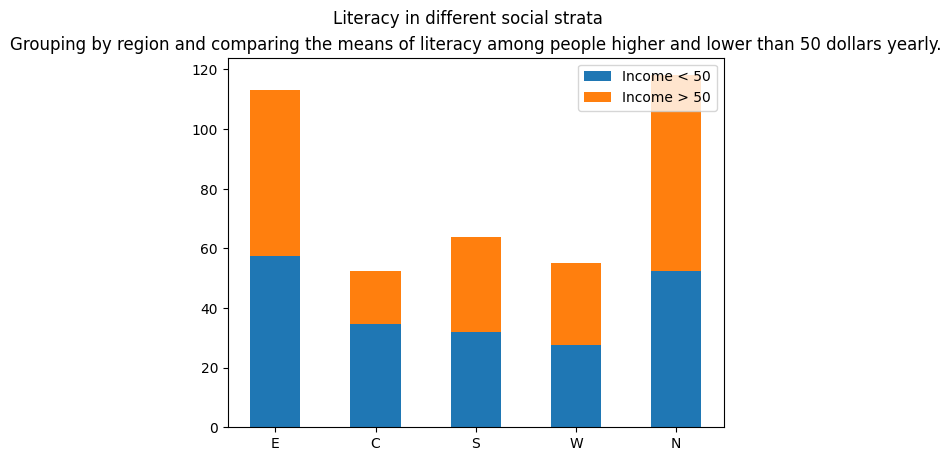

In [38]:
regs

upperHLit = [upperHDatE["Literacy"], upperHDatC["Literacy"], upperHDatS["Literacy"], upperHDatW["Literacy"], upperHDatN["Literacy"]]
lowELit = [LowerEDatE["Literacy"], LowerEDatC["Literacy"], LowerEDatS["Literacy"], LowerEDatW["Literacy"], LowerEDatN["Literacy"]]

literacyValUH = [x for x in map(np.mean, upperHLit)]
literacyValLE = [x for x in map(np.mean, lowELit)]

wealthS = {
    "Income < 50": literacyValLE,
    "Income > 50": literacyValUH
}
width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(5)

for boolean, wealth in wealthS.items():
    p = ax.bar(regs, wealth, width, label = boolean, bottom=bottom)
    bottom += wealth

ax.set_title("Grouping by region and comparing the means of literacy among people higher and lower than 50 dollars yearly.")
# ax.set_sub("Grouping by region and comparing the means of literacy among people higher and lower than 50 Thousand dollars yearly.")
ax.legend(loc="upper right")

plt.suptitle("Literacy in different social strata")
# plt.title()
plt.show()




In [15]:
literacyValUH

[np.float64(55.6),
 np.float64(18.0),
 np.float64(32.0),
 np.float64(27.444444444444443),
 np.float64(65.5)]

In [14]:
literacyValLE

[np.float64(57.57142857142857),
 np.float64(34.5),
 np.float64(31.8),
 np.float64(27.75),
 np.float64(52.53333333333333)]

In [ ]:

# Do the same plot but with each social strata easier to compare. Add pairs of bars together assigned by strata
# and separate the pair by region.


In [19]:
# The cumulative value childs registered at a region
def byRegion(y:str, opMap:str):
    '''
    Output the values of 
    '''
    upperHDat = dat[dat["Wealth"] >= 50]
    regs = upperHDat["Region"].unique()
    
    upperHDatE = upperHDat[upperHDat['Region'] == regs[0] ]
    upperHDatC = upperHDat[upperHDat['Region'] == regs[1] ]
    upperHDatS = upperHDat[upperHDat['Region'] == regs[2] ]
    upperHDatW = upperHDat[upperHDat['Region'] == regs[3] ]
    upperHDatN = upperHDat[upperHDat['Region'] == regs[4] ]

    upperHDatval = [upperHDatE[y], upperHDatC[y], upperHDatS[y], upperHDatW[y], upperHDatN[y]]
    if opMap == "mean":
        upperHDLookOutVal = [x for x in map(np.mean, upperHDatval)]
    else:
        pass
    
    lowerEDat = dat[dat["Wealth"] < 50]
    
    lowerEDatE = lowerEDat[LowerEDat['Region'] == regs[0] ]
    lowerEDatC = lowerEDat[LowerEDat['Region'] == regs[1] ]
    lowerEDatS = lowerEDat[LowerEDat['Region'] == regs[2] ]
    lowerEDatW = lowerEDat[LowerEDat['Region'] == regs[3] ]
    lowerEDatN = lowerEDat[LowerEDat['Region'] == regs[4] ]

    lowerEDatval = [lowerEDatE[y], lowerEDatC[y], lowerEDatS[y], lowerEDatW[y], lowerEDatN[y]]
    if opMap == "mean":
        lowerEDLookOutVal = [x for x in map(np.mean, lowerEDatval)]
    else:
        pass

    return [upperHDLookOutVal, lowerEDLookOutVal]
    
    
    


In [20]:
overF, underF = byRegion('Infants', 'mean')

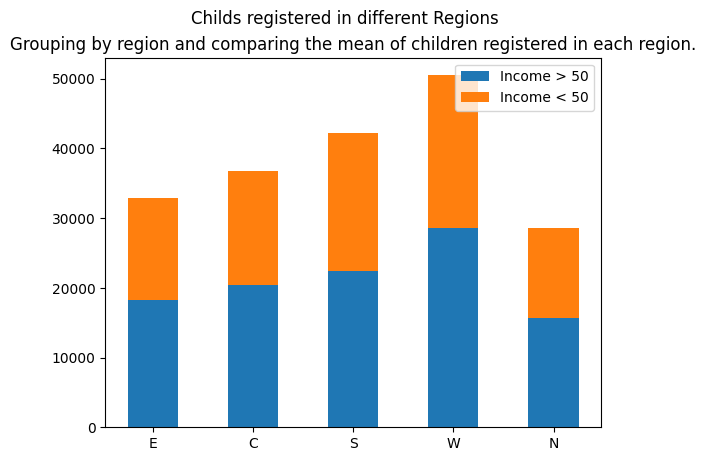

In [24]:
wealthS = {
    "Income > 50": overF,
    "Income < 50": underF
}
width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(5)

for boolean, wealth in wealthS.items():
    p = ax.bar(regs, wealth, width, label=boolean, bottom=bottom)
    bottom += wealth

ax.set_title("Grouping by region and comparing the mean of children registered in each region.")
# ax.set_sub("Grouping by region and comparing the means of literacy among people higher and lower than 50 Thousand dollars yearly.")
ax.legend(loc="upper right")

plt.suptitle("Childs registered in different Regions")
# plt.title()
plt.show()

In [30]:
def meanSalary_Hour(x: int ):
    weekly = x/4
    daily = weekly / 7
    hourly = daily / 5

    print(f"The hourly value of the given monnthly salary is: {hourly}", 
        f"this amounts a daily value of : {daily}", 
          f"considering each week the amount is: {weekly}")
    return hourly, daily, weekly


In [31]:
meanSalary_Hour(2733)

The hourly value of the given monnthly salary is: 19.521428571428572 this amounts a daily value of : 97.60714285714286 considering each week the amount is: 683.25


(19.521428571428572, 97.60714285714286, 683.25)